In [18]:
%load_ext autoreload
%autoreload 2

# Applying Apriori to the uncovered_transactions dataset


In [19]:
import sys

sys.path.append("../../../common_code")
from paths import PATH_ROOT
from helpers import *
from apriori import V33

## Configuration


In [20]:
DB_DIR = "./example_data"
UNCOVERED_TRX_DB = DB_DIR + "/uncovered_transactions.db"

## Workflow

Init apriori instance.


In [21]:
# init apriori
uncovered_transactions = V33(file_path=UNCOVERED_TRX_DB)

Fetch the text of transaction phrases.


In [22]:
%%time
import pandas as pd
phrases = uncovered_transactions.get_phrases(verb='neelama', verb_compound='alla')
df = pd.DataFrame.from_dict(phrases)
#df.to_csv('fraasid.csv', index=None)
print(f"transactions total: {df.shape[0]}")
df.head()

transactions total: 573
CPU times: user 3.7 ms, sys: 2.49 ms, total: 6.19 ms
Wall time: 6.38 ms


,head_id,loc,phrase,sentence_id
0,67,13,näen neelan konksu alla,47
1,20682,7,ta neelas alla selle,12013
2,39579,13,selle alla neelad,23006
3,96282,11,siis neelab publik pilgutamata klõmpsti alla,55595
4,153261,17,mis elukad nad Traadi näol tegelikult alla nee...,90454


Apply the Apriori algorithm to the transactions.


************************************************ neelama  alla ************************************************
Ridu analüüsimiseks: 536
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemlists,drop,drop_reason,length
4,0.669776,"[(NSUBJ, nom, , )]",False,,1
5,0.514925,"[(OBJ, gen, , )]",False,,1
1,0.402985,"[(ADVMOD, , , )]",False,,1
13,0.343284,"[(NSUBJ, nom, , ), (OBJ, gen, , )]",False,,2
6,0.270522,"[(OBJ, nom, , )]",False,,1
8,0.259328,"[(NSUBJ, nom, , ), (ADVMOD, , , )]",False,,2
9,0.208955,"[(OBJ, gen, , ), (ADVMOD, , , )]",False,,2
14,0.190299,"[(NSUBJ, nom, , ), (OBJ, nom, , )]",False,,2
15,0.147388,"[(NSUBJ, nom, , ), (OBJ, gen, , ), (ADVMOD, , ...",False,,3
10,0.110075,"[(OBJ, nom, , ), (ADVMOD, , , )]",False,,2


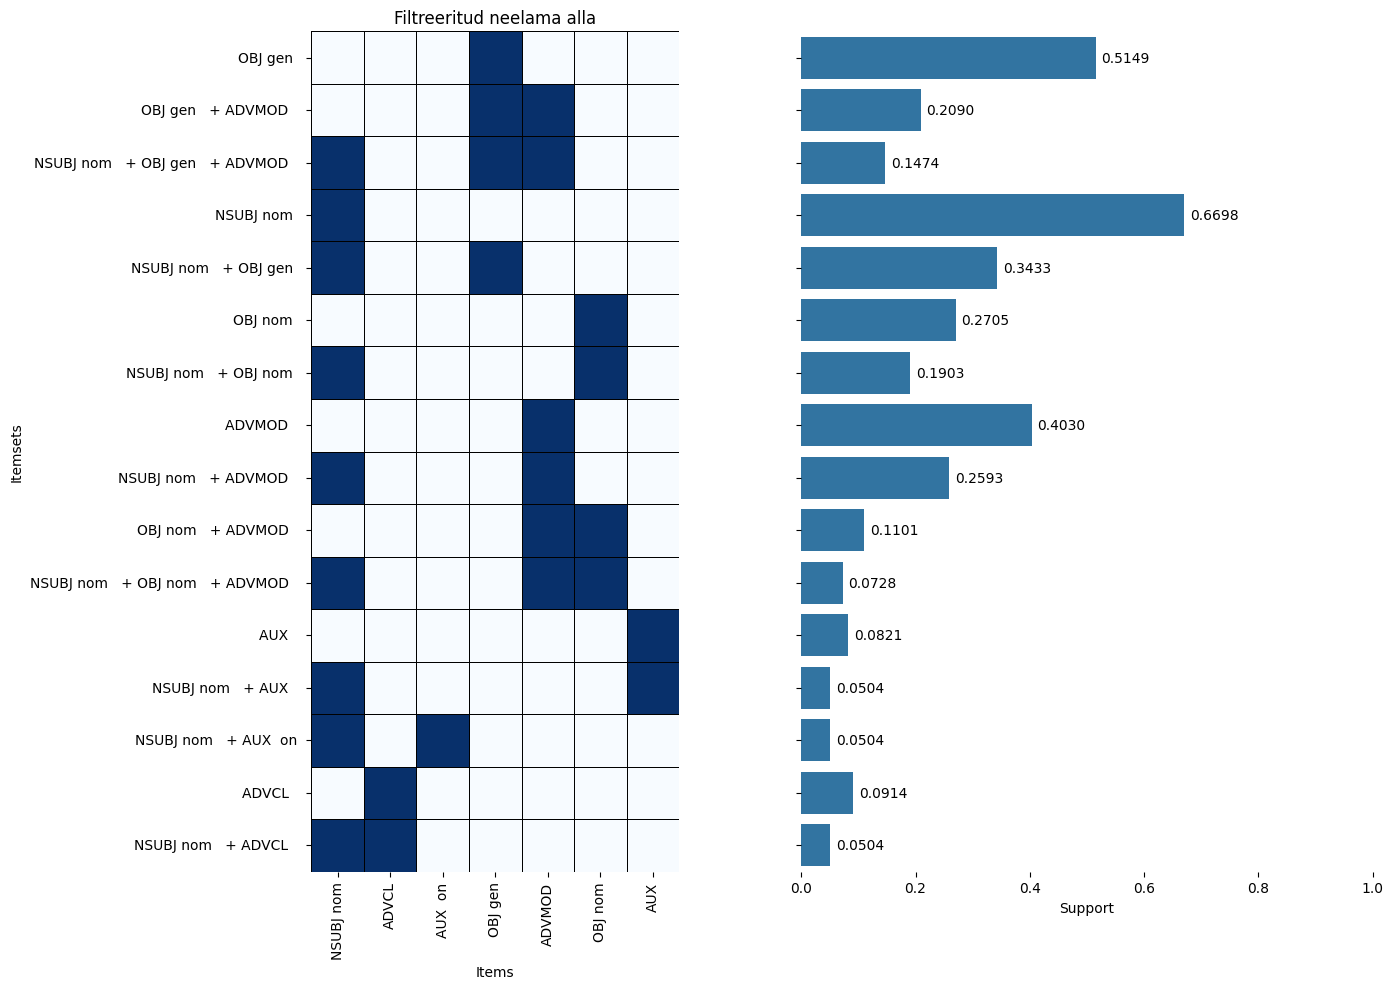

CPU times: user 298 ms, sys: 20.5 ms, total: 319 ms
Wall time: 331 ms


In [23]:
%%time
uncovered_transactions.make_all(verb='neelama', verb_compound='alla')

************************************************ aasima   ************************************************
Ridu analüüsimiseks: 103
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemlists,drop,drop_reason,length
4,0.786408,"[(NSUBJ, nom, , )]",False,,1
1,0.233010,"[(ADVMOD, , , )]",False,,1
7,0.135922,"[(NSUBJ, nom, , ), (ADVMOD, , , )]",False,,2
0,0.126214,"[(ADVCL, , , )]",True,(row 6) delta: abs(0.1165 - 0.1262) < 0.03 %: ...,1
6,0.116505,"[(NSUBJ, nom, , ), (ADVCL, , , )]",False,,2
3,0.087379,"[(CCOMP, , , )]",True,(row 8) delta: abs(0.0583 - 0.0874) < 0.03 %: ...,1
8,0.058252,"[(NSUBJ, nom, , ), (CCOMP, , , )]",False,,2
2,0.058252,"[(AUX, , , )]",False,,1
5,0.058252,"[(OBL, kom, , )]",False,,1


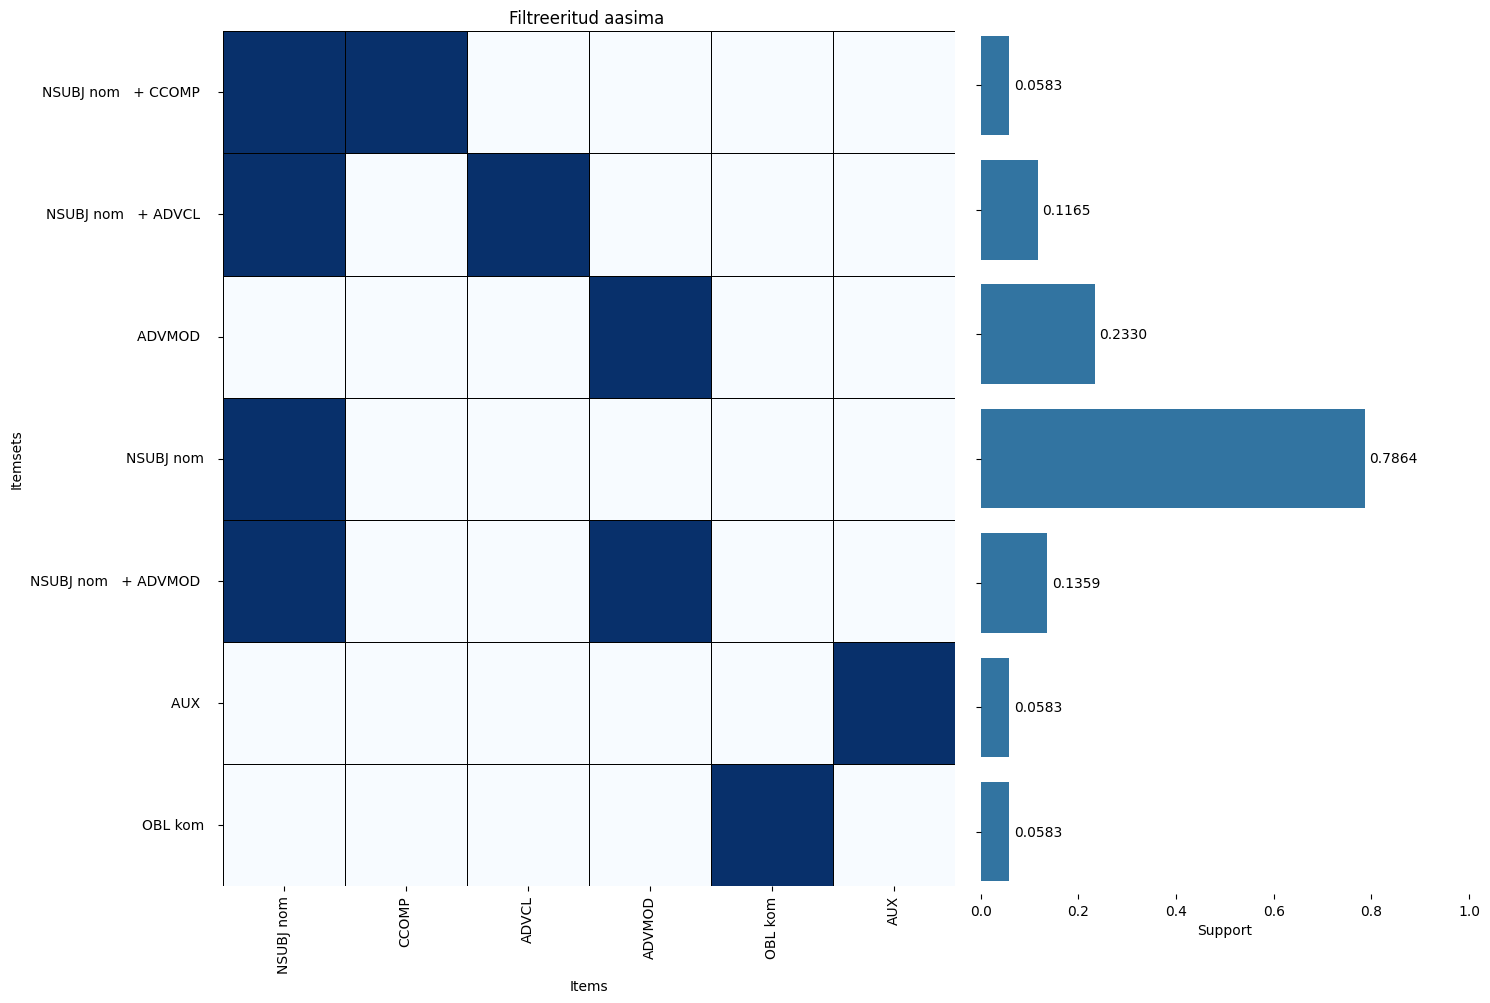

In [24]:
uncovered_transactions.make_all(verb="aasima", verb_compound="")

In [25]:
uncovered_transactions._conn.close()